In [14]:
from nn.taylr import dataset, model
from physics.hstar import gghzz, c6
from physics.simulation import msq
from physics.hzz import zpair, angles, kinematics

import os
import json
import numpy as np
import matplotlib.pyplot as plt

import hist

In [15]:
SEED=373485

BASE_SIZE=200000
SAMPLE_DIR='..'

In [16]:
sample = gghzz.Process(msq.Component.SBI, (1.5, os.path.join(SAMPLE_DIR, 'ggZZ2e2m_sbi.csv'), 1.2*BASE_SIZE))

In [17]:
z_chooser = zpair.ZPairChooser(bounds1=(70,115), bounds2=(70,115), algorithm='leastsquare')
leptons = sample.events.filter(z_chooser)

kin_vars = np.array([[el.px, el.py, el.pz, el.E] for el in leptons]).reshape(16,leptons[0].shape[0]).T

sample.events = sample.events[:BASE_SIZE]
kin_vars = kin_vars[:BASE_SIZE]

In [18]:
def filter_to_ranges(bounds):
    #ranges_min = np.array(ranges)[:,0]
    #ranges_max = np.array(ranges)[:,1]

    m4l_filter = angles.M4lFilter(m4l_min=bounds[0], m4l_max=bounds[1])

    #l1_filter = kinematics.MomentumFilter(lepton_index=0, momenta_min=ranges_min[:4], momenta_max=ranges_max[:4])
    #l2_filter = kinematics.MomentumFilter(lepton_index=1, momenta_min=ranges_min[4:8], momenta_max=ranges_max[4:8])
    #l3_filter = kinematics.MomentumFilter(lepton_index=2, momenta_min=ranges_min[8:12], momenta_max=ranges_max[8:12])
    #l4_filter = kinematics.MomentumFilter(lepton_index=3, momenta_min=ranges_min[12:16], momenta_max=ranges_max[12:16])

    sample_filtered = object.__new__(gghzz.Process)
    sample_filtered.baseline = sample.baseline
    sample_filtered.events = sample.events[:]

    #sample_filtered.events.filter(l1_filter)
    #sample_filtered.events.filter(l2_filter)
    #sample_filtered.events.filter(l3_filter)
    #sample_filtered.events.filter(l4_filter)

    sample_filtered.events.filter(m4l_filter)

    c6_mod = c6.Modifier(baseline = msq.Component.SBI, sample=sample_filtered, c6_values = [-5,-1,0,1,5])
    coeff = c6_mod.coefficients

    return (sample_filtered, coeff)

In [19]:
def generate_histogram(targets, weights, num_bins, bounds):
    histogram = hist.Hist(hist.axis.Regular(num_bins, bounds[0], bounds[1], name='x', label='NN output []'))
    histogram.fill(targets, weight=weights)

    return histogram.to_numpy()

In [63]:
def plot_histograms(histograms, xlim, colors, labels):
    fig = plt.figure(figsize=(7,6))

    for i in range(len(histograms)):
        histogram = histograms[i]
        color = colors[i]
        label = labels[i]
        plt.step(histogram[1][1:], histogram[0], color=color, label=label, alpha=0.6)

    plt.xlabel('coefficient []')
    plt.ylabel('Percentage of predictions []')
    plt.legend()
    plt.xlim(xlim[0],xlim[1])
    plt.yscale('log')

    plt.show()

In [36]:
index = 2348

kin_at_ind = kin_vars[index]
pm_100_ranges = [[el-np.abs(el), el+np.abs(el)] for el in kin_at_ind]
pm_50_ranges = [[el-0.5*np.abs(el), el+0.5*np.abs(el)] for el in kin_at_ind]
pm_25_ranges = [[el-0.25*np.abs(el), el+0.25*np.abs(el)] for el in kin_at_ind]
pm_10_ranges = [[el-0.1*np.abs(el), el+0.1*np.abs(el)] for el in kin_at_ind]

In [84]:
index = 32190

# i = 32185: m4l = 385 GeV
# i = 32190: m4l = 545 GeV

m4l_at_ind = (leptons[0][index] + leptons[1][index] + leptons[2][index] + leptons[3][index]).mass

c6_mod = c6.Modifier(baseline = msq.Component.SBI, sample=sample, c6_values = [-5,-1,0,1,5])
coeffs_at_ind = c6_mod.coefficients[index]

print(m4l_at_ind, coeffs_at_ind)

pm_100_bounds = [m4l_at_ind - m4l_at_ind, m4l_at_ind + m4l_at_ind]
pm_50_bounds = [m4l_at_ind - 0.5*m4l_at_ind, m4l_at_ind + 0.5*m4l_at_ind]
pm_10_bounds = [m4l_at_ind - 0.1*m4l_at_ind, m4l_at_ind + 0.1*m4l_at_ind]
pm_1_bounds = [m4l_at_ind - 0.01*m4l_at_ind, m4l_at_ind + 0.01*m4l_at_ind]

545.8410366729742 [ 1.00000000e+00 -8.27488962e-05 -2.77425744e-05 -1.18422649e-07
  5.99247140e-09]


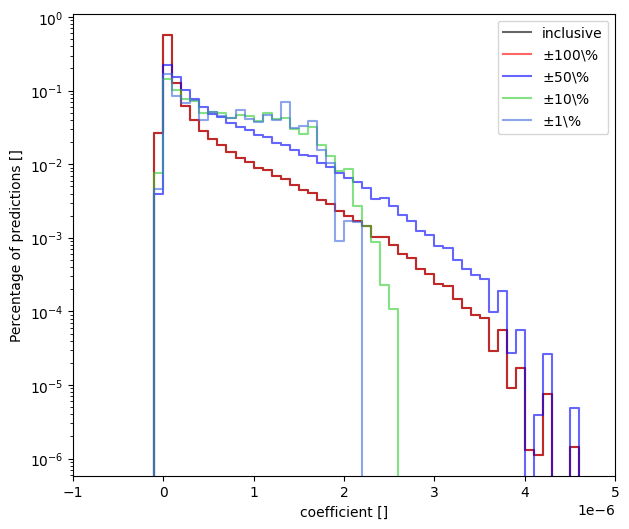

In [95]:
bounds = (-1e-6,5e-6)
bins = 60

histograms = []

for pm_bounds in [[-np.inf,np.inf], pm_100_bounds, pm_50_bounds, pm_10_bounds, pm_1_bounds]:
    sample_filtered, coeff = filter_to_ranges(pm_bounds)
    histogram = generate_histogram(coeff[:,4] - coeffs_at_ind[4], sample_filtered.events.probabilities, bins, bounds)
    histograms.append(histogram)

labels = ['inclusive', u'$\pm100$\%', u'$\pm50$\%', u'$\pm10$\%', u'$\pm1$\%']
colors = ['k', 'r', 'b', 'limegreen', 'royalblue']

plot_histograms(histograms, xlim=bounds, colors=colors, labels=labels)